In [4]:
import os
import torch
import yaml
from DataLoaders.transforms import get_train_img_transform_1, get_train_img_transform_2, get_train_img_transform_3

from DataLoaders.dataloaders import create_dataloader
from Losses import get_loss
from Metrics import get_metrics
from Model import get_model
from Training.evaluator import Evaluator
from Training.trainer import Trainer
from utils.logger import get_logger, TensorboardLogger
from utils.misc import get_device

cfg_path = "/home/loai/Documents/code/RSMLExtraction/RSA_deep_working/Models/config.yml"
assert os.path.exists(cfg_path), f"Le fichier de config n'existe pas : {cfg_path}"
with open(cfg_path, "r") as f:
    config = yaml.safe_load(f)

train_loader, val_loader, test_loader, series_val_loader, series_test_loader = create_dataloader(
    base_directory=config["data"]["base_dir"],
    img_transforms=[
        get_train_img_transform_1(patch_size=512), 
        get_train_img_transform_2(patch_size=512), 
        get_train_img_transform_3(patch_size=512)
        ],
    default_batch_size=int(config["data"].get("batch_size", 32)),
    seed=42
)

device = get_device(preferred=config["training"].get("device", "cuda"))

model = get_model(config["model"])
model = model.to(device)

criterion = get_loss(config["loss"])
try:
    criterion = criterion.to(device)
except:
    pass

optimizer_name = config["optimizer"]["name"]
lr = float(config["optimizer"]["learning_rate"])
weight_decay = float(config["optimizer"].get("weight_decay", 0))
if optimizer_name.lower() == "adam":
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
else:
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

metrics_dict = get_metrics(config["metrics"])

logger = get_logger("/home/loai/Documents/code/RSMLExtraction/RSA_deep_working/Models/log_file.log")

tb_log_dir = os.path.join(config["training"]["checkpoint_dir"], "tensorboard_logs")
os.makedirs(tb_log_dir, exist_ok=True)
tb_logger = TensorboardLogger(log_dir=tb_log_dir)

#from torch_lr_finder import LRFinder
#lr_finder = LRFinder(model, optimizer, criterion, device="cuda")
#lr_finder.range_test(train_loader, end_lr=1, num_iter=200)
#lr_finder.plot() # to inspect the loss-learning rate graph
#lr_finder.reset() # to reset the model and optimizer to their initial state


evaluator = Evaluator(
    model=model,
    val_dataloader=val_loader,
    test_dataloader=test_loader,
    val_series_dataloader=series_val_loader,
    test_series_dataloader=series_test_loader,
    metrics=metrics_dict,
    device=device,
    logger=logger,
    threshold=config["metrics"].get("threshold", 0.5),
    tb_logger=tb_logger,
    jar_path=config["rst"].get("jar_path",
                                "/home/loai/Documents/code/RSMLExtraction/RootSystemTracker/target/rootsystemtracker-1.6.1-jar-with-dependencies.jar"),
)

trainer = Trainer(
    model=model,
    train_loader=train_loader,
    criterion=criterion,
    optimizer=optimizer,
    config=config,
    evaluator=evaluator,
    logger=logger,
    tb_logger=tb_logger,
    device=device,
)


2025-06-11 15:39:07,968 INFO: [Evaluator] Initialisation terminée.
2025-06-11 15:39:07,968 INFO: [Evaluator] Initialisation terminée.
2025-06-11 15:39:07,970 INFO: [Trainer] Device : cuda
2025-06-11 15:39:07,970 INFO: [Trainer] Device : cuda


Total series: 29
Total images: 841
Number of Training series : 20
Number of Validation series : 5
Number of Testing series : 4
Number of Training images : 580
Number of Validation images : 145
Number of Testing images : 116

Number of transformed images: 841 (dataset 1), 841 (dataset 2), 841 (dataset 3)


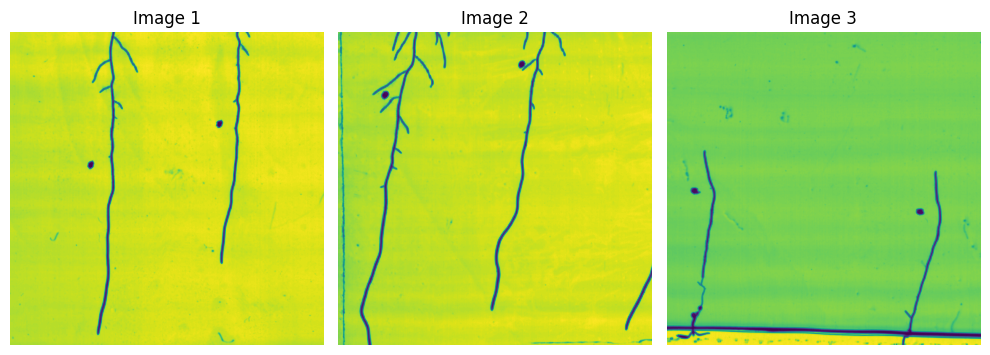

In [6]:
# plot batch 
batch = next(iter(train_loader))
images, masks, time, mtg_list = batch
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 10))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.imshow(images[i].permute(1, 2, 0).cpu().numpy())
    plt.title(f"Image {i+1}")
    plt.axis('off')
plt.tight_layout()
plt.show()

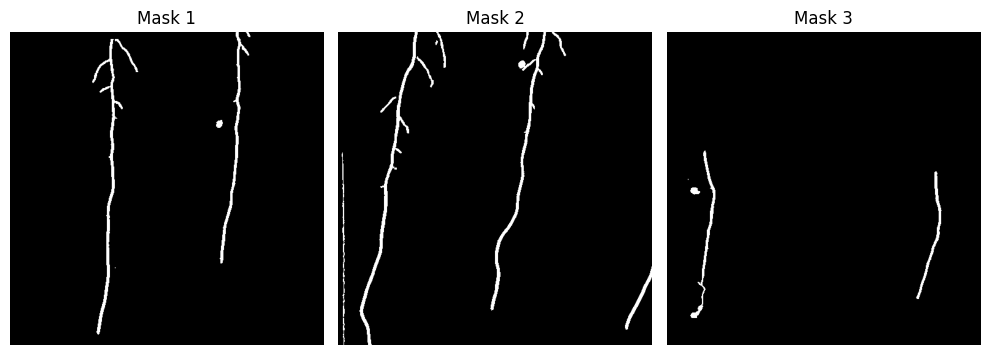

In [8]:
# corresponding masks
plt.figure(figsize=(10, 10))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.imshow(masks[i][0].cpu().numpy(), cmap='gray')
    plt.title(f"Mask {i+1}")
    plt.axis('off')
plt.tight_layout()
plt.show()